In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

plt.rcParams["figure.figsize"] = (12,6)

sns.set_style("whitegrid")

In [2]:
nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

aum = pd.read_csv(
    "../data/processed/clean_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    "../data/processed/clean_monthly_sip_inflows.csv"
)

category = pd.read_csv(
    "../data/processed/clean_category_inflows.csv"
)

txn = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

folios = pd.read_csv(
    "../data/processed/clean_industry_folio_count.csv"
)

portfolio = pd.read_csv(
    "../data/processed/clean_portfolio_holdings.csv"
)

funds = pd.read_csv(
    "../data/processed/clean_fund_master.csv"
)

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(sip["month"])

category["month"] = pd.to_datetime(category["month"])

folios["month"] = pd.to_datetime(folios["month"])

In [4]:
sample_funds = (
    nav["amfi_code"]
    .unique()[:10]
)

fig = px.line(

    nav[
        nav["amfi_code"]
        .isin(sample_funds)
    ],

    x="date",

    y="nav",

    color="amfi_code",

    title="NAV Trends (2022-2026)"

)

fig.show()

In [5]:
fig.add_vrect(

    x0="2023-01-01",

    x1="2023-12-31",

    fillcolor="green",

    opacity=0.1

)

In [6]:
fig.add_vrect(

    x0="2024-01-01",

    x1="2024-06-30",

    fillcolor="red",

    opacity=0.1

)

In [7]:
%pip install -U kaleido

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import sys

print(sys.executable)

c:\Users\Saiashish\AppData\Local\Programs\Python\Python312\python.exe


In [9]:
!python -m pip install -U kaleido


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
fig.write_image(
    r"C:/Users/Saiashish/Desktop/Mutual-Fund-Analytics/reports/charts/nav_trends.png"
)

### Insight 1
Most schemes experienced strong NAV appreciation during the 2023 market rally, followed by moderate corrections during early 2024.

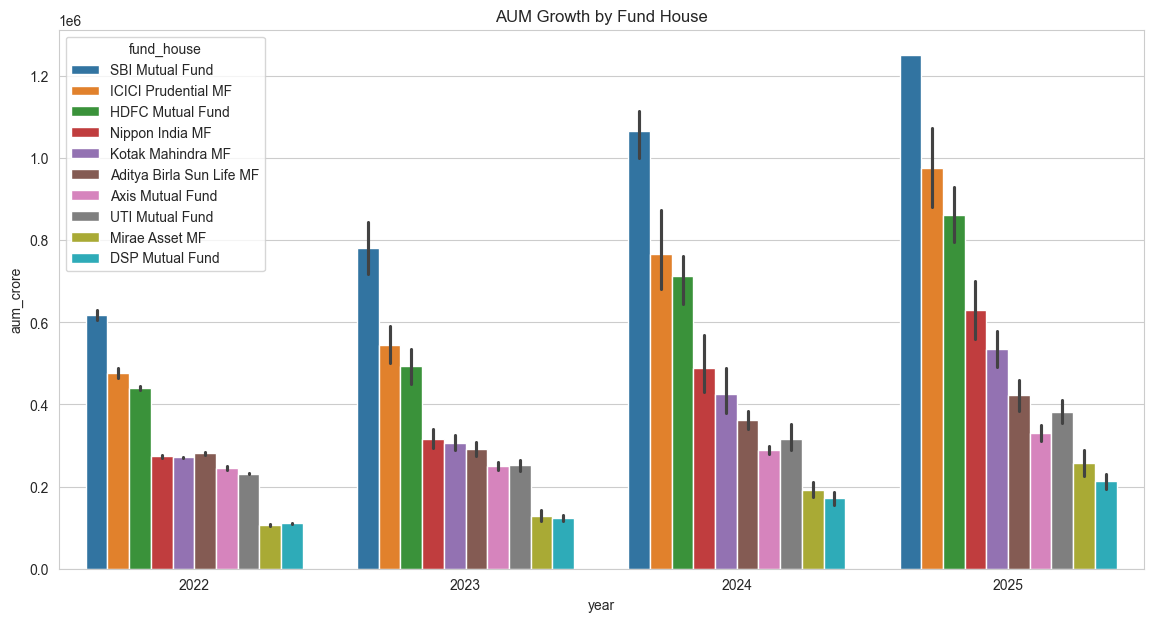

In [12]:
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,7))

sns.barplot(

    data=aum,

    x="year",

    y="aum_crore",

    hue="fund_house"

)

plt.title(
    "AUM Growth by Fund House"
)

plt.savefig(
    "../reports/charts/aum_growth.png"
)

plt.show()

### Insight 2
SBI Mutual Fund maintained the highest AUM throughout the period, reaching approximately ₹12.5 lakh crore by 2025.

In [13]:
fig = px.line(

    sip,

    x="month",

    y="sip_inflow_crore",

    title="Monthly SIP Inflows"

)

fig.add_annotation(

    x="2025-12-01",

    y=31002,

    text="All-Time High ₹31,002 Cr"

)

fig.show()

In [14]:
fig.write_image(
    "../reports/charts/sip_trend.png"
)

Resorting to unclean kill browser.


### Insight 3
Monthly SIP inflows more than doubled between 2022 and 2025, reaching a record ₹31,002 crore in December 2025.

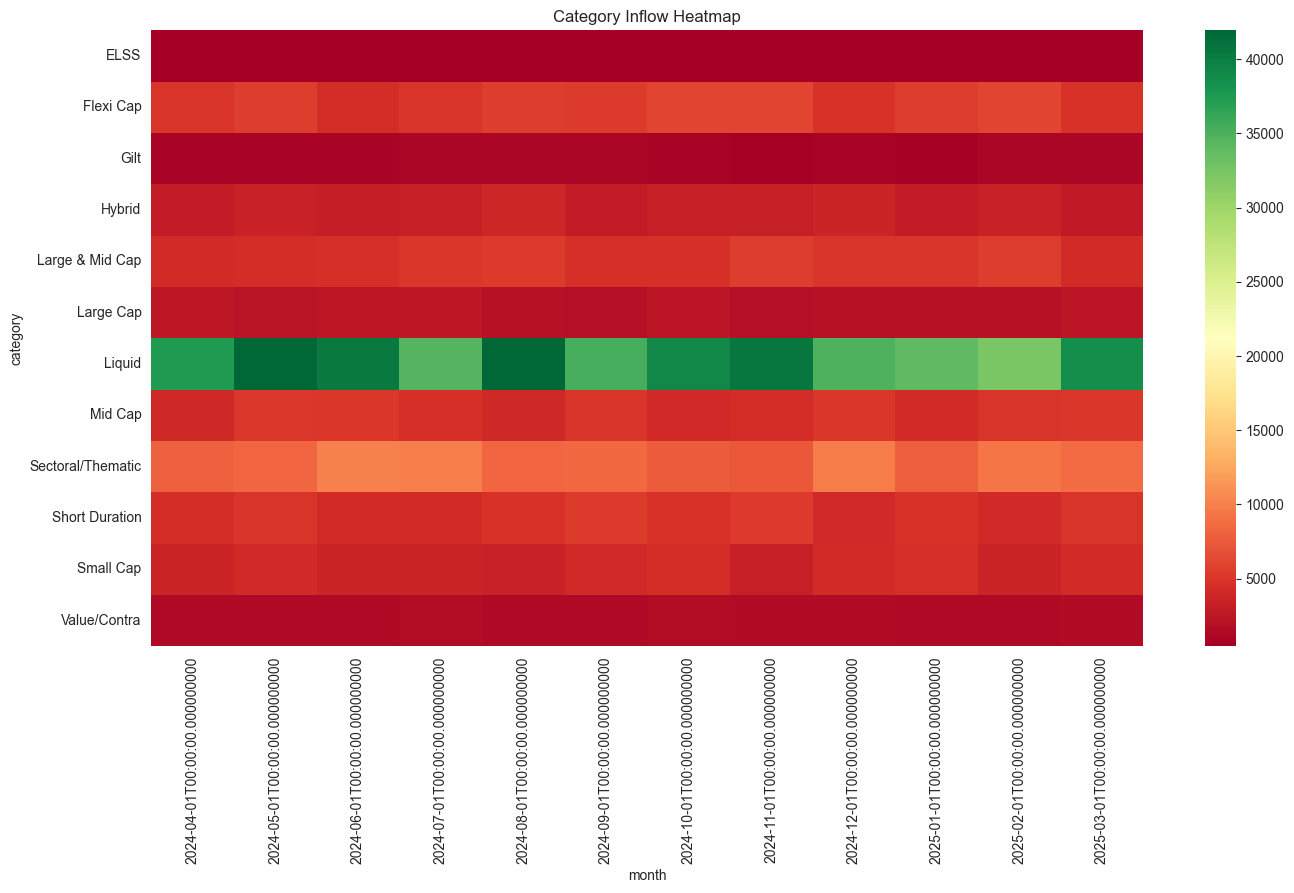

In [15]:
pivot = category.pivot(

    index="category",

    columns="month",

    values="net_inflow_crore"

)

plt.figure(figsize=(16,8))

sns.heatmap(

    pivot,

    cmap="RdYlGn"

)

plt.title(
    "Category Inflow Heatmap"
)

plt.savefig(
    "../reports/charts/category_heatmap.png"
)

plt.show()

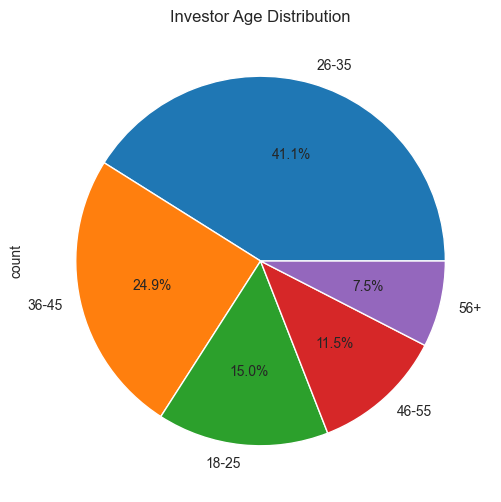

In [16]:
txn["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "Investor Age Distribution"
)

plt.savefig(
    "../reports/charts/age_distribution.png"
)

plt.show()

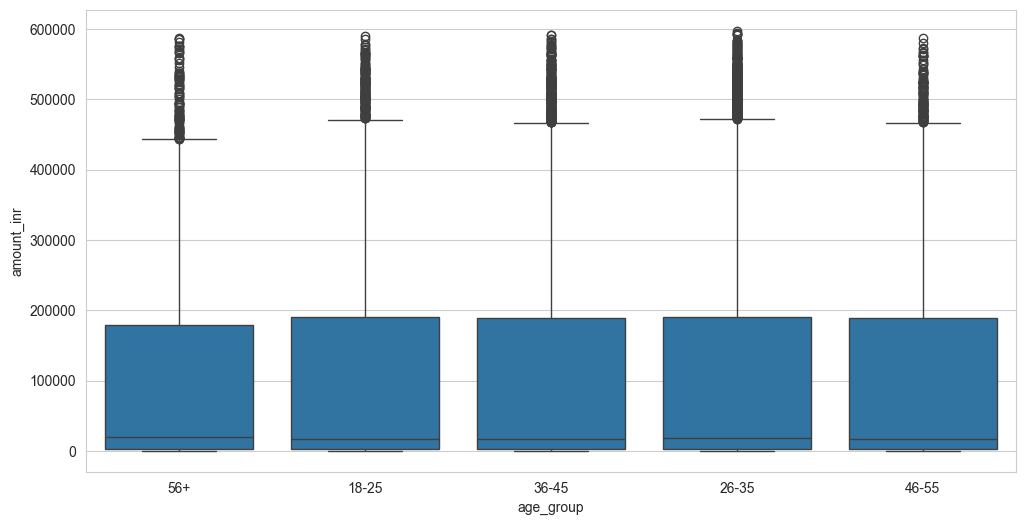

In [17]:
sns.boxplot(

    data=txn,

    x="age_group",

    y="amount_inr"

)

plt.savefig(
    "../reports/charts/sip_boxplot_age.png"
)

plt.show()

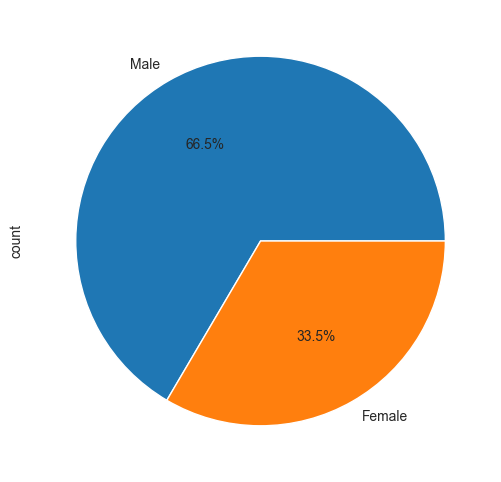

In [18]:
txn["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.savefig(
    "../reports/charts/gender_split.png"
)

plt.show()

### Insight 4
Investors aged 26–35 form the largest investor segment.

### Insight 5
Male investors account for approximately two-thirds of transactions.

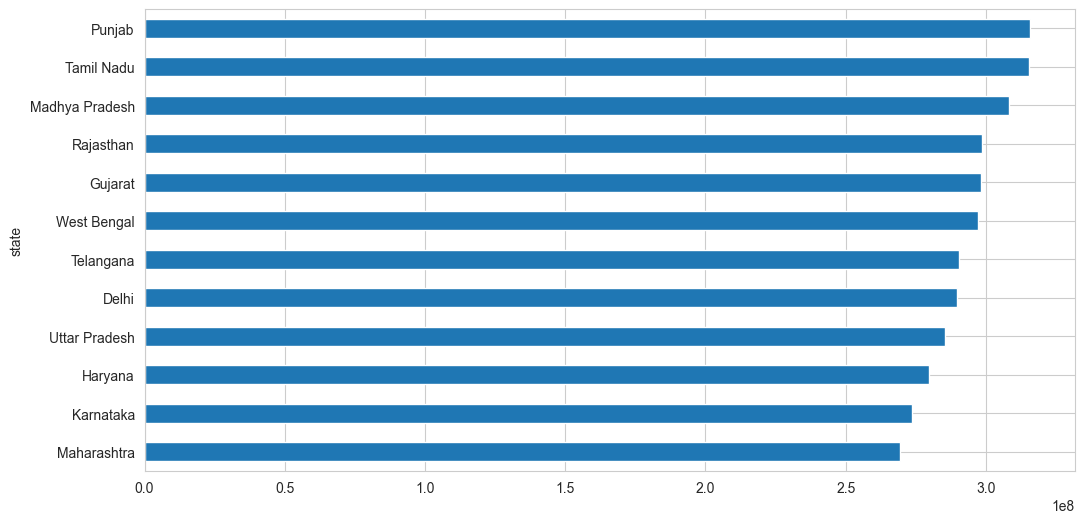

In [19]:
state_data = (

    txn.groupby("state")
       ["amount_inr"]
       .sum()
       .sort_values()

)

state_data.plot(
    kind="barh"
)

plt.savefig(
    "../reports/charts/state_distribution.png"
)

plt.show()

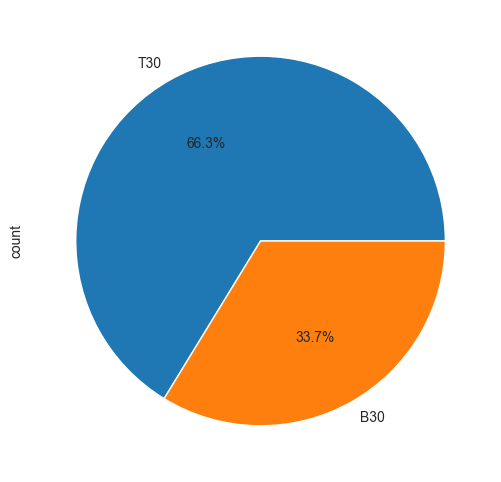

In [20]:
txn["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.savefig(
    "../reports/charts/city_tier_distribution.png"
)

plt.show()

### Insight 6
T30 cities contribute nearly two-thirds of total investment activity.

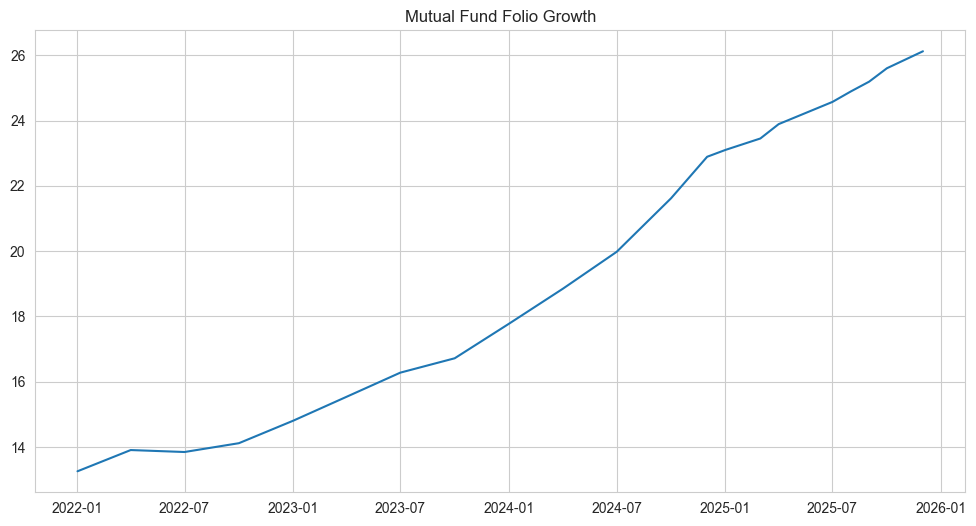

In [21]:
plt.plot(

    folios["month"],

    folios["total_folios_crore"]

)

plt.title(
    "Mutual Fund Folio Growth"
)

plt.savefig(
    "../reports/charts/folio_growth.png"
)

plt.show()

### Insight 7
Industry folios nearly doubled from 13.26 crore to over 26 crore during the study period.

In [22]:
nav["daily_return"] = (

    nav.groupby("amfi_code")
       ["nav"]
       .pct_change()

)

In [23]:
selected = nav["amfi_code"].unique()[:10]

In [24]:
corr_df = (

    nav[
        nav["amfi_code"]
        .isin(selected)
    ]

    .pivot(

        index="date",

        columns="amfi_code",

        values="daily_return"

    )

)

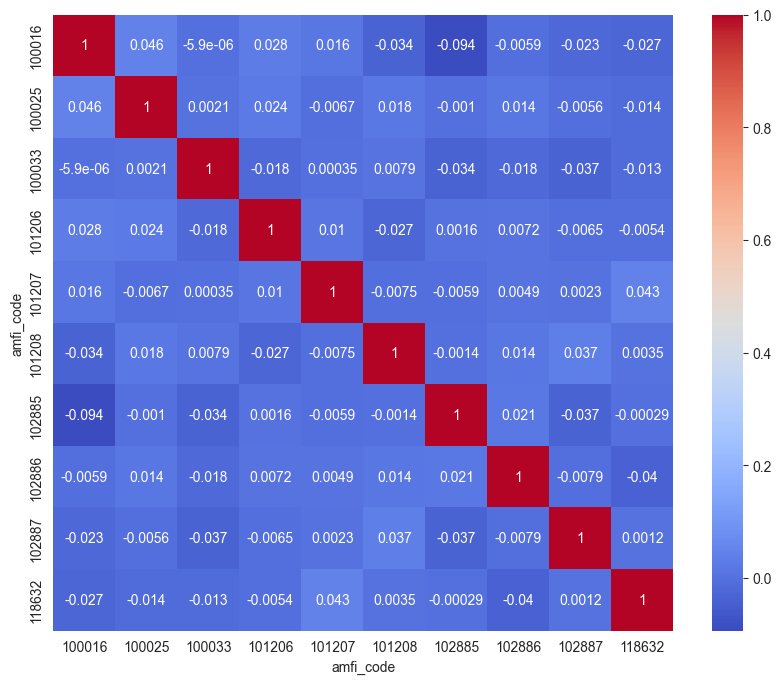

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(

    corr_df.corr(),

    annot=True,

    cmap="coolwarm"

)

plt.savefig(
    "../reports/charts/correlation_matrix.png"
)

plt.show()

### Insight 8
Large-cap equity funds exhibit strong positive correlations, indicating common exposure to market-wide movements.

In [26]:
sector = (

    portfolio.groupby("sector")
             ["weight_pct"]
             .sum()

)

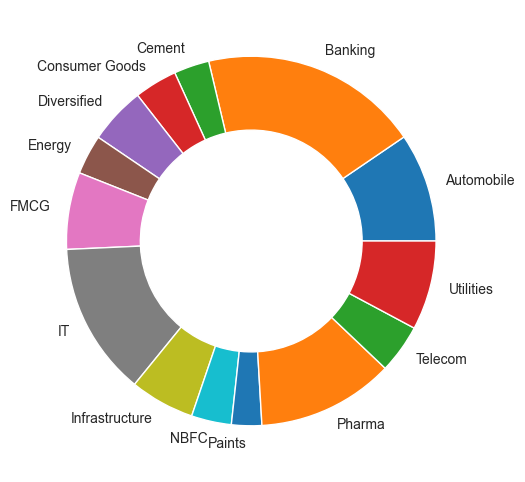

In [27]:
plt.pie(

    sector,

    labels=sector.index,

    wedgeprops={
        "width":0.4
    }

)

plt.savefig(
    "../reports/charts/sector_allocation.png"
)

plt.show()

### Insight 9
Banking is the largest sector allocation across equity fund portfolios.

### Insight 10
IT and Pharma together account for a significant share of portfolio exposure, highlighting growth-oriented sector preferences.